In [1]:
import gymnasium as gym
import matplotlib
import numpy as np
import sys

from collections import defaultdict
from itertools import product
from lib.envs.blackjack import BlackjackEnv
from lib import plotting
matplotlib.style.use('ggplot')

In [2]:
env = BlackjackEnv()

In [3]:
def mc_control_epsilon_greedy(env, num_episodes, discount_factor=1.0, epsilon=0.1):
    """
    Monte Carlo Control using Epsilon-Greedy policies.
    Finds an optimal epsilon-greedy policy.
    
    Args:
        env: Gymnasium environment.
        num_episodes: Number of episodes to sample.
        discount_factor: Gamma discount factor.
        epsilon: Chance the sample a random action. Float betwen 0 and 1.
    
    Returns:
        A tuple (Q, policy).
        Q is a dictionary mapping state -> action values.
        policy is a dictionary that maps state -> action probabilities
    """
    
    Q = {}
    policy = {}

    # In these dictionaries we store the sum of returns per state-action pair and the amount of time we visited them
    # This is different from the book where we have a list per state-action pair. This saves space and is more efficient.
    returns_sum = {}
    returns_count = {}
    
    # Initialize values for our dictionaries. States are the tuples: (player sum, dealer card, usable ace)
    for s in product(range(12, 22), range(1, 11), (False, True)):
        Q[s] = {}
        # Our initial policy chooses the first action as optimal
        policy[s] = np.ones(env.action_space.n)*epsilon/env.action_space.n
        policy[s][0] += 1-epsilon
        for a in range(env.action_space.n):
            Q[s][a] = 0
            returns_sum[s, a] = 0  
            returns_count[s, a] = 0
    
    # Loop for number of episodes
    for i in range(1, num_episodes+1):
        # Generate an episode
        episode = []
        state = env.reset()
        for t in range(100):
            # Obtain action probabilities
            action_probs = policy[state]
            # Sample an action
            action = np.random.choice(np.arange(len(action_probs)), p=action_probs)
            
            # Sample from the environment
            next_state, reward, done, _ = env.step(action)
            # Episode is a list of state, action reward tuples
            episode.append((state, action, reward))
            # Quit the episode if we reach a terminal state
            if done:
                break
            state = next_state
        
        # Update the state-action pairs visited in the loop
        # Determine length of the episode and loop over it
        T = len(episode)
        G = 0
        # Determine first appearance times of each state-action pair in the episode and store in dictionary
        first_appearance = {(episode[t][0], episode[t][1]): t for t in range(T-1, -1, -1)}
        for t in range(T-1, -1, -1):
            # Select state action reward tuple
            state, action, reward = episode[t]
            G = discount_factor*G + reward
            # If first appareance, update Q function
            if t == first_appearance[(state, action)]:
                # Add G to returns and increment visit count
                returns_sum[state, action] += G
                returns_count[state, action] += 1.0
                
                # Update Q function
                Q[state][action] = returns_sum[state, action]/returns_count[state, action]
                
                # Update policy
                best_action = max(Q[state], key=Q[state].get)
                for a in range(env.action_space.n):
                    policy[state][a] = epsilon/env.action_space.n
                    if a == best_action:
                        policy[state][a] += 1 - epsilon
        
        # Print every 1000 episodes
        if i % 1000 == 0:
            print("\rEpisode {}/{}.".format(i, num_episodes), end="")
            sys.stdout.flush()
        
    return Q, policy

In [4]:
Q, policy = mc_control_epsilon_greedy(env, num_episodes=500000, epsilon=0.1)

Episode 500000/500000.

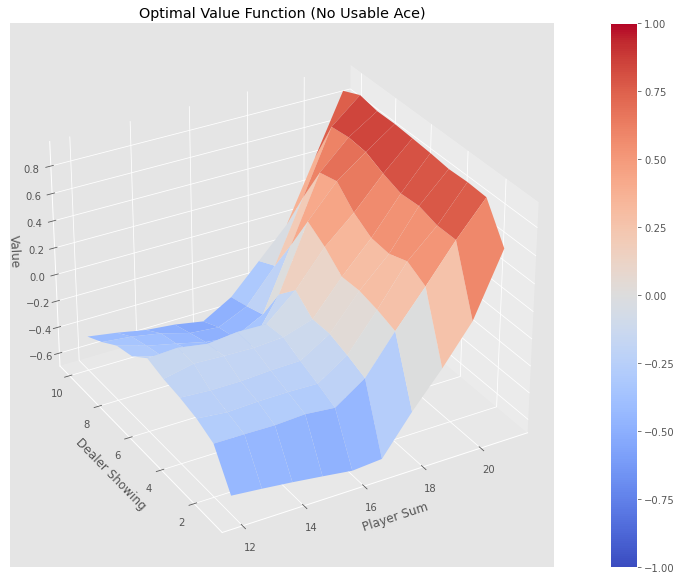

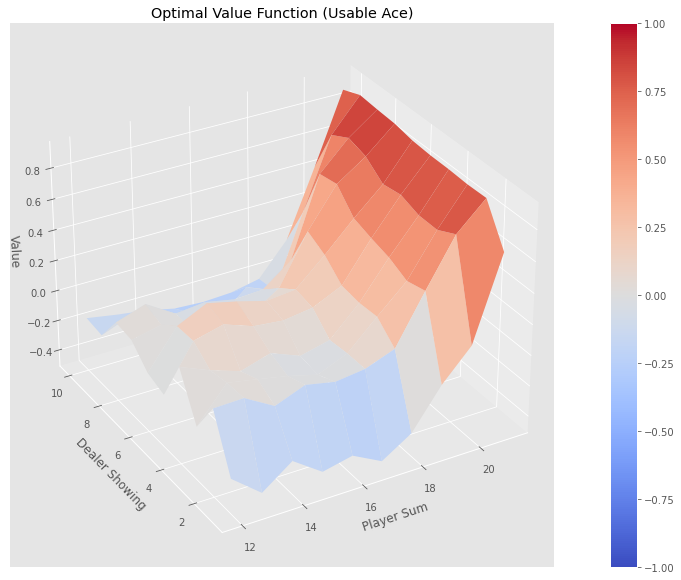

In [5]:
# For plotting: Create value function from action-value function
# by picking the best action at each state
V = {}
for state, actions in Q.items():
    action_value = np.max(list(actions.values()))
    V[state] = action_value
plotting.plot_value_function(V, title="Optimal Value Function")